# Modèles de deep learning pour l'analyse de sentiment (PyTorch)

Quatre combinaisons LSTM / BiLSTM avec embeddings pré-entraînés GloVe 200d et FastText 300d, en PyTorch (équivalent du notebook Keras `04_model_avance_keras_backup.ipynb`).

TensorFlow >= 2.11 ne supporte plus le GPU natif sous Windows. PyTorch utilise CUDA directement, comme dans le notebook BERTweet.


## 1. Configuration


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

import mlflow
import mlflow.pytorch

mlflow.set_tracking_uri("sqlite:///D:/code/Projet7/notebooks/mlflow.db")
mlflow.set_experiment("deep_learning")
print("MLflow version :", mlflow.__version__)
print("Expérience définie : deep_learning")


MLflow version : 3.11.1
Experiment defini : deep_learning


In [2]:
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
print(f"Nombre de GPU   : {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU utilisé     : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version    : {torch.version.cuda}")
    DEVICE = torch.device("cuda")
else:
    print("Aucun GPU détecté - PyTorch tourne sur CPU")
    DEVICE = torch.device("cpu")

torch.manual_seed(42)
np.random.seed(42)


PyTorch version : 2.6.0+cu124
CUDA disponible : True
Nombre de GPU   : 1
GPU utilise     : NVIDIA GeForce RTX 2070
CUDA version    : 12.4


## 2. Chargement des données preprocessées


In [3]:
DATA_DIR = "../data"

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

X_train = train_df["text_clean"].astype(str).values
y_train = train_df["target"].values.astype(np.float32)
X_val = val_df["text_clean"].astype(str).values
y_val = val_df["target"].values.astype(np.float32)
X_test = test_df["text_clean"].astype(str).values
y_test = test_df["target"].values.astype(np.float32)

print(f"Train : {len(X_train)} exemples")
print(f"Val   : {len(X_val)} exemples")
print(f"Test  : {len(X_test)} exemples")
train_df.head(3)


Train : 1273984 exemples
Val   : 159248 exemples
Test  : 159249 exemples


,target,text,text_clean
0,1,@JJcrew no she really is! she did the nasty t...,really nasty today haha
1,1,&quot;I Wanna&quot; stuck in my head!!! ..I w...,quoti wannaquot stuck head wan na wan na wan n...
2,1,@cbirk aww if life was all sunshine and lollip...,aww life sunshine lollipop would awesome


## 3. Vocabulaire et tokenisation

Pas de Keras Tokenizer en PyTorch : on construit un vocabulaire (MAX_WORDS plus fréquents) puis on encode les tweets en séquences d'entiers, padded à MAX_LEN.


In [4]:
MAX_WORDS = 50000
MAX_LEN   = 100
PAD_IDX   = 0
UNK_IDX   = 1

def build_vocab(texts, max_words):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    most_common = counter.most_common(max_words - 2)
    vocab = {"<pad>": PAD_IDX, "<unk>": UNK_IDX}
    for i, (w, _) in enumerate(most_common, start=2):
        vocab[w] = i
    return vocab

vocab = build_vocab(X_train, MAX_WORDS)
print(f"Vocabulaire total dans le train : {len(set(w for t in X_train for w in t.split()))} mots uniques")
print(f"Vocabulaire retenu : {len(vocab)} entrées (incluant <pad> et <unk>)")

def encode(text, vocab, max_len):
    ids = [vocab.get(w, UNK_IDX) for w in text.split()][:max_len]
    if len(ids) < max_len:
        # pre-padding (comme Keras) pour aligner les fins de séquence
        ids = [PAD_IDX] * (max_len - len(ids)) + ids
    return ids

X_train_seq = np.array([encode(t, vocab, MAX_LEN) for t in X_train], dtype=np.int64)
X_val_seq   = np.array([encode(t, vocab, MAX_LEN) for t in X_val],   dtype=np.int64)
X_test_seq  = np.array([encode(t, vocab, MAX_LEN) for t in X_test],  dtype=np.int64)

print(f"Forme X_train_seq : {X_train_seq.shape}")


Vocabulaire total dans le train : 350703 mots uniques
Vocabulaire retenu : 50000 entrees (incluant <pad> et <unk>)
Forme X_train_seq : (1273984, 100)


## 4. Chargement des embeddings

Fichiers pré-entraînés chargés depuis `../data/embeddings/`. La matrice est alignée sur le vocabulaire construit ci-dessus.


In [5]:
EMBEDDINGS_DIR = "../data/embeddings"
GLOVE_PATH    = os.path.join(EMBEDDINGS_DIR, "glove.twitter.27B.200d.txt")
FASTTEXT_PATH = os.path.join(EMBEDDINGS_DIR, "fasttext-wiki-news-subwords-300.vec")

def load_embeddings(filepath, vocab, embedding_dim, skip_header=False):
    embeddings_index = {}
    with open(filepath, encoding="utf-8") as f:
        if skip_header:
            next(f)
        for line in f:
            values = line.rstrip().split(" ")
            word = values[0]
            coefs = np.asarray(values[1:], dtype="float32")
            if coefs.shape[0] == embedding_dim:
                embeddings_index[word] = coefs
    print(f"  {len(embeddings_index)} vecteurs chargés depuis {os.path.basename(filepath)}")

    matrix = np.zeros((len(vocab), embedding_dim), dtype=np.float32)
    found = 0
    for word, idx in vocab.items():
        vec = embeddings_index.get(word)
        if vec is not None:
            matrix[idx] = vec
            found += 1
    coverage = found / len(vocab) * 100
    print(f"  Couverture du vocabulaire : {found}/{len(vocab)} ({coverage:.1f} %)")
    return matrix

print("Chargement des embeddings GloVe (200d)...")
glove_matrix    = load_embeddings(GLOVE_PATH, vocab, embedding_dim=200, skip_header=False)
print("\nChargement des embeddings FastText (300d)...")
fasttext_matrix = load_embeddings(FASTTEXT_PATH, vocab, embedding_dim=300, skip_header=True)

print(f"\nForme matrice GloVe    : {glove_matrix.shape}")
print(f"Forme matrice FastText : {fasttext_matrix.shape}")


Chargement des embeddings GloVe (200d)...
  1193514 vecteurs charges depuis glove.twitter.27B.200d.txt
  Couverture du vocabulaire : 42155/50000 (84.3 %)

Chargement des embeddings FastText (300d)...
  999999 vecteurs charges depuis fasttext-wiki-news-subwords-300.vec
  Couverture du vocabulaire : 33664/50000 (67.3 %)

Forme matrice GloVe    : (50000, 200)
Forme matrice FastText : (50000, 300)


## 5. Définition du modèle

Architecture équivalente au notebook Keras : Embedding (frozen) + Dropout(0.3) + LSTM ou BiLSTM(64) + Linear(64, relu) + Dropout(0.5) + Linear(1).

`BCEWithLogitsLoss` donc pas de sigmoid dans le forward.


In [6]:
class TweetClassifier(nn.Module):
    def __init__(self, embedding_matrix, lstm_type="lstm", hidden_size=64,
                 input_dropout=0.3, head_dropout=0.5):
        super().__init__()
        vocab_size, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.from_numpy(embedding_matrix), freeze=True, padding_idx=PAD_IDX,
        )
        self.input_dropout = nn.Dropout(input_dropout)
        bidirectional = (lstm_type == "bilstm")
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=bidirectional,
        )
        out_size = hidden_size * (2 if bidirectional else 1)
        self.fc1 = nn.Linear(out_size, 64)
        self.relu = nn.ReLU()
        self.head_dropout = nn.Dropout(head_dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        emb = self.embedding(x)
        emb = self.input_dropout(emb)
        out, (h, c) = self.lstm(emb)
        if self.lstm.bidirectional:
            last = torch.cat([h[0], h[1]], dim=1)
        else:
            last = h[0]
        x = self.relu(self.fc1(last))
        x = self.head_dropout(x)
        return self.fc2(x).squeeze(-1)

sample = TweetClassifier(glove_matrix, lstm_type="lstm")
n_params = sum(p.numel() for p in sample.parameters())
n_trainable = sum(p.numel() for p in sample.parameters() if p.requires_grad)
print(f"Total params     : {n_params:,}")
print(f"Trainable params : {n_trainable:,}")
print(sample)


Total params     : 10,072,321
Trainable params : 72,321
TweetClassifier(
  (embedding): Embedding(50000, 200, padding_idx=0)
  (input_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(200, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (relu): ReLU()
  (head_dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


## 6. Entraînement des 4 combinaisons avec MLflow

Chaque configuration tourne dans un run MLflow distinct, avec early-stopping (patience=3) et ReduceLROnPlateau (factor=0.5, patience=2). `batch_size=512` sur GPU, descendre à 256 si la VRAM est trop juste.


In [7]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

BATCH_SIZE = 512
EPOCHS     = 10
PATIENCE   = 3

train_loader = DataLoader(SeqDataset(X_train_seq, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(SeqDataset(X_val_seq,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(SeqDataset(X_test_seq,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f"Batches train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")


Batches train: 2489 | val: 312 | test: 312


In [8]:
def evaluate(model, loader, criterion):
    model.eval()
    losses, preds, labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            losses.append(loss.item() * xb.size(0))
            preds.append((torch.sigmoid(logits) > 0.5).cpu().numpy())
            labels.append(yb.cpu().numpy())
    preds = np.concatenate(preds)
    labels = np.concatenate(labels)
    avg_loss = sum(losses) / len(loader.dataset)
    return avg_loss, preds, labels

def train_one(cfg, embedding_matrix):
    model = TweetClassifier(embedding_matrix, lstm_type=cfg["lstm_type"]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)
    criterion = nn.BCEWithLogitsLoss()

    history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses, preds_e, labels_e = [], [], []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            losses.append(loss.item() * xb.size(0))
            preds_e.append((torch.sigmoid(logits) > 0.5).detach().cpu().numpy())
            labels_e.append(yb.detach().cpu().numpy())
        train_loss = sum(losses) / len(train_loader.dataset)
        train_acc  = accuracy_score(np.concatenate(labels_e), np.concatenate(preds_e))

        val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion)
        val_acc = accuracy_score(val_labels, val_preds)
        scheduler.step(val_loss)

        history["loss"].append(train_loss);     history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss);   history["val_accuracy"].append(val_acc)
        print(f"  epoch {epoch:>2} | loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"  early-stopping déclenché à l'époque {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

configs = [
    {"name": "lstm_glove",      "lstm_type": "lstm",   "matrix": glove_matrix,    "dim": 200},
    {"name": "lstm_fasttext",   "lstm_type": "lstm",   "matrix": fasttext_matrix, "dim": 300},
    {"name": "bilstm_glove",    "lstm_type": "bilstm", "matrix": glove_matrix,    "dim": 200},
    {"name": "bilstm_fasttext", "lstm_type": "bilstm", "matrix": fasttext_matrix, "dim": 300},
]

histories = {}
results   = {}
trained_models = {}

for cfg in configs:
    print(f"\n{'='*60}\nEntraînement : {cfg['name']}\n{'='*60}")
    with mlflow.start_run(run_name=cfg["name"]):
        mlflow.log_param("framework",     "pytorch")
        mlflow.log_param("lstm_type",     cfg["lstm_type"])
        mlflow.log_param("embedding",     cfg["name"].split("_")[1])
        mlflow.log_param("embedding_dim", cfg["dim"])
        mlflow.log_param("max_words",     MAX_WORDS)
        mlflow.log_param("max_len",       MAX_LEN)
        mlflow.log_param("batch_size",    BATCH_SIZE)
        mlflow.log_param("epochs_max",    EPOCHS)

        model, history = train_one(cfg, cfg["matrix"])
        histories[cfg["name"]] = history
        trained_models[cfg["name"]] = model

        _, y_pred, y_true = evaluate(model, test_loader, nn.BCEWithLogitsLoss())
        acc  = accuracy_score(y_true, y_pred)
        f1   = f1_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred)
        rec  = recall_score(y_true, y_pred)

        mlflow.log_metric("test_accuracy",  acc)
        mlflow.log_metric("test_f1",        f1)
        mlflow.log_metric("test_precision", prec)
        mlflow.log_metric("test_recall",    rec)

        results[cfg["name"]] = {"accuracy": acc, "f1": f1, "precision": prec, "recall": rec}

        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax)
        ax.set_title(f"Matrice de confusion - {cfg['name']}")
        mlflow.log_figure(fig, "confusion_matrix.png")
        plt.close(fig)

        torch.save(model.state_dict(), f"{cfg['name']}_best.pt")
        mlflow.pytorch.log_model(model, "model")
        run_id = mlflow.active_run().info.run_id
        mlflow.register_model(f"runs:/{run_id}/model", cfg["name"])

        print(f"  test_accuracy  : {acc:.4f}")
        print(f"  test_f1        : {f1:.4f}")
        print(f"  test_precision : {prec:.4f}")
        print(f"  test_recall    : {rec:.4f}")

print("\nEntraînement terminé pour les 4 configurations.")


2026/05/07 23:06:04 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet




Entrainement : lstm_glove
  epoch  1 | loss=0.4883 acc=0.7642 | val_loss=0.4497 val_acc=0.7884
  epoch  2 | loss=0.4607 acc=0.7827 | val_loss=0.4406 val_acc=0.7936
  epoch  3 | loss=0.4524 acc=0.7879 | val_loss=0.4349 val_acc=0.7970
  epoch  4 | loss=0.4471 acc=0.7911 | val_loss=0.4322 val_acc=0.7989
  epoch  5 | loss=0.4435 acc=0.7932 | val_loss=0.4305 val_acc=0.7999
  epoch  6 | loss=0.4412 acc=0.7950 | val_loss=0.4277 val_acc=0.8018
  epoch  7 | loss=0.4386 acc=0.7959 | val_loss=0.4282 val_acc=0.8018
  epoch  8 | loss=0.4375 acc=0.7972 | val_loss=0.4282 val_acc=0.8008
  epoch  9 | loss=0.4360 acc=0.7975 | val_loss=0.4270 val_acc=0.8020
  epoch 10 | loss=0.4348 acc=0.7982 | val_loss=0.4256 val_acc=0.8026


2026/05/07 23:12:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 23:12:07 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/07 23:12:07 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/07 23:12:20 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+

  test_accuracy  : 0.8007
  test_f1        : 0.8022
  test_precision : 0.7963
  test_recall    : 0.8081

Entrainement : lstm_fasttext
  epoch  1 | loss=0.5249 acc=0.7389 | val_loss=0.4775 val_acc=0.7701
  epoch  2 | loss=0.4878 acc=0.7662 | val_loss=0.4657 val_acc=0.7803
  epoch  3 | loss=0.4756 acc=0.7743 | val_loss=0.4585 val_acc=0.7843
  epoch  4 | loss=0.4682 acc=0.7785 | val_loss=0.4535 val_acc=0.7876
  epoch  5 | loss=0.4628 acc=0.7818 | val_loss=0.4530 val_acc=0.7860
  epoch  6 | loss=0.4588 acc=0.7846 | val_loss=0.4451 val_acc=0.7912
  epoch  7 | loss=0.4551 acc=0.7867 | val_loss=0.4425 val_acc=0.7929
  epoch  8 | loss=0.4526 acc=0.7880 | val_loss=0.4407 val_acc=0.7933
  epoch  9 | loss=0.4503 acc=0.7892 | val_loss=0.4408 val_acc=0.7939
  epoch 10 | loss=0.4484 acc=0.7909 | val_loss=0.4368 val_acc=0.7961


2026/05/07 23:18:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 23:18:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/07 23:18:56 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/07 23:19:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+

  test_accuracy  : 0.7951
  test_f1        : 0.7987
  test_precision : 0.7847
  test_recall    : 0.8133

Entrainement : bilstm_glove
  epoch  1 | loss=0.4878 acc=0.7646 | val_loss=0.4502 val_acc=0.7879
  epoch  2 | loss=0.4604 acc=0.7830 | val_loss=0.4407 val_acc=0.7928
  epoch  3 | loss=0.4519 acc=0.7882 | val_loss=0.4366 val_acc=0.7966
  epoch  4 | loss=0.4469 acc=0.7914 | val_loss=0.4328 val_acc=0.7984
  epoch  5 | loss=0.4434 acc=0.7932 | val_loss=0.4311 val_acc=0.7989
  epoch  6 | loss=0.4410 acc=0.7947 | val_loss=0.4284 val_acc=0.8011
  epoch  7 | loss=0.4389 acc=0.7959 | val_loss=0.4261 val_acc=0.8021
  epoch  8 | loss=0.4376 acc=0.7967 | val_loss=0.4261 val_acc=0.8017
  epoch  9 | loss=0.4361 acc=0.7978 | val_loss=0.4278 val_acc=0.8017
  epoch 10 | loss=0.4349 acc=0.7984 | val_loss=0.4267 val_acc=0.8027
  early-stopping declenche a l'epoch 10


2026/05/07 23:28:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 23:28:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/07 23:28:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/07 23:28:10 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+

  test_accuracy  : 0.8000
  test_f1        : 0.8009
  test_precision : 0.7969
  test_recall    : 0.8049

Entrainement : bilstm_fasttext
  epoch  1 | loss=0.5249 acc=0.7392 | val_loss=0.4786 val_acc=0.7718
  epoch  2 | loss=0.4881 acc=0.7663 | val_loss=0.4653 val_acc=0.7785
  epoch  3 | loss=0.4768 acc=0.7735 | val_loss=0.4611 val_acc=0.7812
  epoch  4 | loss=0.4692 acc=0.7783 | val_loss=0.4524 val_acc=0.7862
  epoch  5 | loss=0.4638 acc=0.7815 | val_loss=0.4470 val_acc=0.7895
  epoch  6 | loss=0.4593 acc=0.7842 | val_loss=0.4451 val_acc=0.7903
  epoch  7 | loss=0.4560 acc=0.7860 | val_loss=0.4414 val_acc=0.7922
  epoch  8 | loss=0.4530 acc=0.7877 | val_loss=0.4414 val_acc=0.7934
  epoch  9 | loss=0.4507 acc=0.7895 | val_loss=0.4389 val_acc=0.7944
  epoch 10 | loss=0.4485 acc=0.7906 | val_loss=0.4371 val_acc=0.7955


2026/05/07 23:39:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 23:39:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/07 23:39:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/07 23:39:22 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+

  test_accuracy  : 0.7945
  test_f1        : 0.7948
  test_precision : 0.7935
  test_recall    : 0.7961

Entrainement termine pour les 4 configurations.


## 7. Comparaison des 4 modèles

Tableau de synthèse des métriques de test et courbes d'apprentissage.


In [9]:
results_df = pd.DataFrame(results).T
results_df.index.name = "modèle"
results_df = results_df.sort_values("f1", ascending=False)
print("Comparaison des modèles (triés par F1 décroissant) :")
display(results_df.style.format("{:.4f}").highlight_max(axis=0, color="lightgreen"))


Comparaison des modeles (tries par F1 decroissant) :


,accuracy,f1,precision,recall
modele,,,,
lstm_glove,0.8007,0.8022,0.7963,0.8081
bilstm_glove,0.8000,0.8009,0.7969,0.8049
lstm_fasttext,0.7951,0.7987,0.7847,0.8133
bilstm_fasttext,0.7945,0.7948,0.7935,0.7961


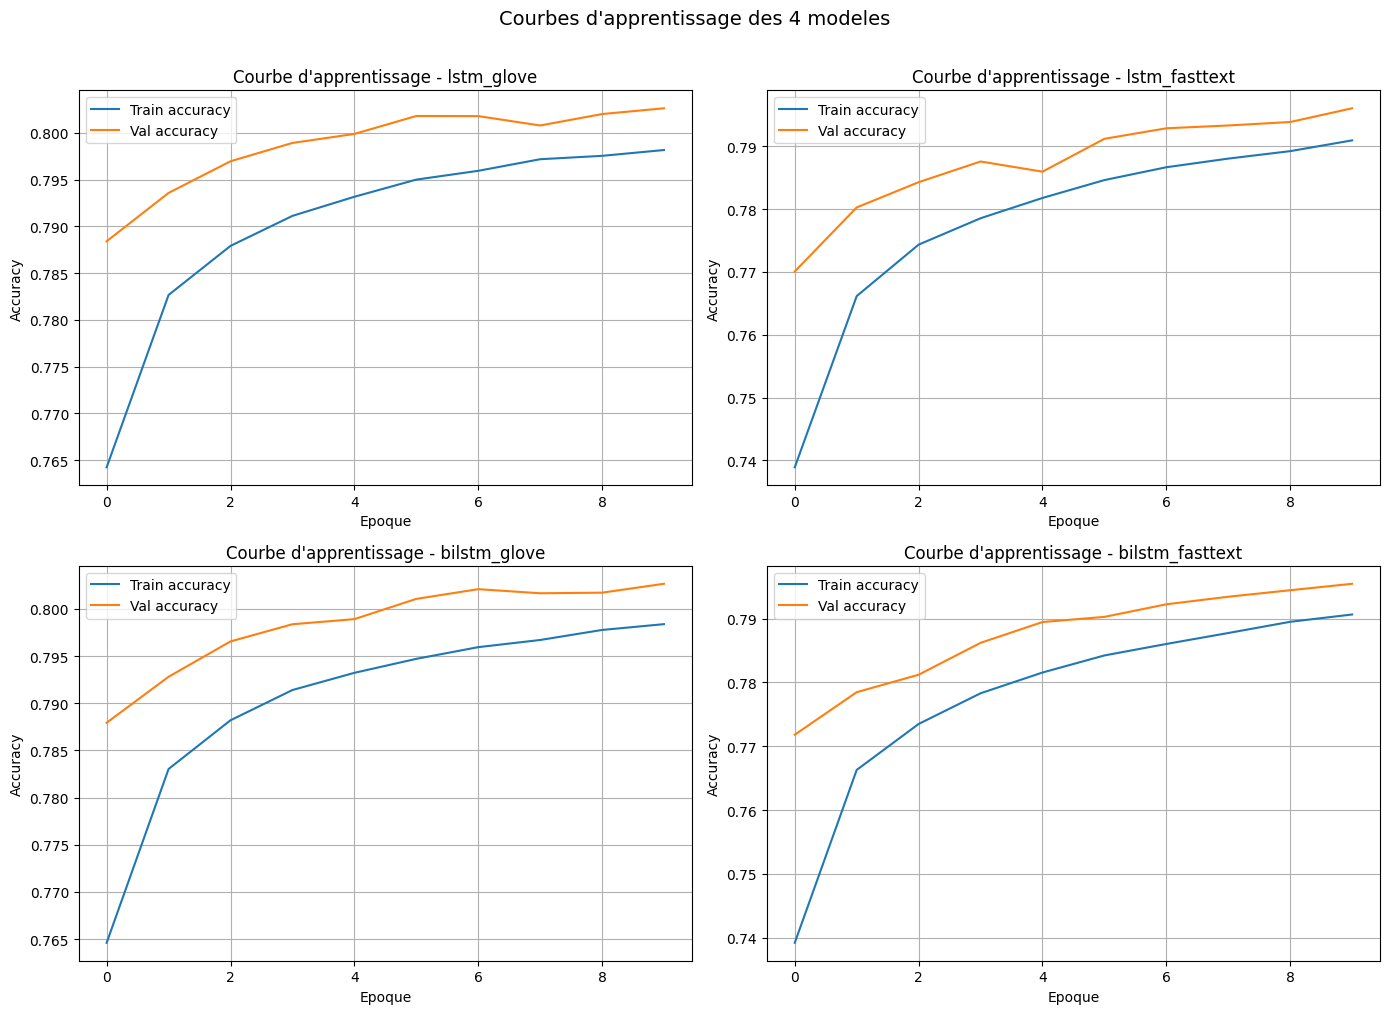

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, (name, hist) in enumerate(histories.items()):
    ax = axes[i]
    ax.plot(hist["accuracy"],     label="Train accuracy")
    ax.plot(hist["val_accuracy"], label="Val accuracy")
    ax.set_title(f"Courbe d'apprentissage - {name}")
    ax.set_xlabel("Époque"); ax.set_ylabel("Accuracy"); ax.legend(); ax.grid(True)
plt.suptitle("Courbes d'apprentissage des 4 modèles", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


## 7bis. Matrice de confusion (lecture business)


Meilleur modele (F1 le plus eleve) : lstm_glove

Matrice de confusion brute (counts) :
  TN =   63187   FP =   16455
  FN =   15278   TP =   64329
  total = 159249

Lecture business :
  - Vrais negatifs (TN) :   63187  (39.7%)  bad buzz correctement detectes
  - Faux positifs (FP)  :   16455  (10.3%)  fausses alertes (positif vu negatif)
  - Faux negatifs (FN)  :   15278  (9.6%)  bad buzz manques (cout business)
  - Vrais positifs (TP) :   64329  (40.4%)  tweets positifs bien identifies


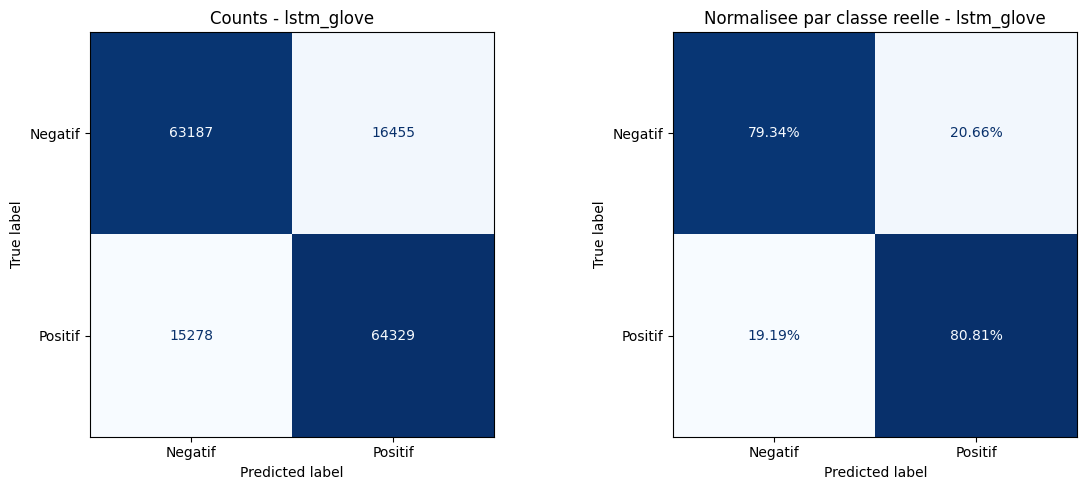

In [11]:
best_model_name = results_df.index[0]
print(f"Meilleur modèle (F1 le plus élevé) : {best_model_name}")

best_model = trained_models[best_model_name]
_, y_pred_best, y_true_best = evaluate(best_model, test_loader, nn.BCEWithLogitsLoss())

cm = confusion_matrix(y_true_best, y_pred_best)
tn, fp, fn, tp = cm.ravel()
total = cm.sum()

print()
print("Matrice de confusion brute (counts) :")
print(f"  TN = {tn:>7d}   FP = {fp:>7d}")
print(f"  FN = {fn:>7d}   TP = {tp:>7d}")
print(f"  total = {total}")

print()
print("Lecture business :")
print(f"  - Vrais négatifs (TN) : {tn:>7d}  ({tn/total:.1%})  bad buzz correctement détectés")
print(f"  - Faux positifs (FP)  : {fp:>7d}  ({fp/total:.1%})  fausses alertes (positif vu négatif)")
print(f"  - Faux négatifs (FN)  : {fn:>7d}  ({fn/total:.1%})  bad buzz manqués (coût business)")
print(f"  - Vrais positifs (TP) : {tp:>7d}  ({tp/total:.1%})  tweets positifs bien identifiés")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm, display_labels=["Négatif", "Positif"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Counts - {best_model_name}")
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=["Négatif", "Positif"]).plot(ax=axes[1], colorbar=False, cmap="Blues", values_format=".2%")
axes[1].set_title(f"Normalisée par classe réelle - {best_model_name}")
plt.tight_layout(); plt.show()


## 8. Sauvegarde du meilleur modèle

Sauvegarde au format `.pt`, vocabulaire exporté en JSON, modèle promu en stage Production dans le registre MLflow.


In [12]:
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

best_model_path = os.path.join(MODELS_DIR, "best_deep_model.pt")
torch.save({
    "state_dict": best_model.state_dict(),
    "lstm_type":  "bilstm" if "bilstm" in best_model_name else "lstm",
    "embedding_dim": best_model.embedding.embedding_dim,
    "vocab_size": best_model.embedding.num_embeddings,
}, best_model_path)
print(f"Modèle sauvegardé : {best_model_path}")

vocab_path = os.path.join(MODELS_DIR, "vocab.json")
with open(vocab_path, "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False)
print(f"Vocabulaire sauvegardé : {vocab_path}")

from mlflow.tracking import MlflowClient
client = MlflowClient()
model_versions = client.search_model_versions(f"name='{best_model_name}'")
if model_versions:
    latest_version = sorted(model_versions, key=lambda v: int(v.version), reverse=True)[0]
    client.transition_model_version_stage(
        name=best_model_name,
        version=latest_version.version,
        stage="Production",
        archive_existing_versions=True,
    )
    print(f"Modèle '{best_model_name}' v{latest_version.version} promu en Production.")
else:
    print("Aucune version trouvée dans le registre MLflow pour ce modèle.")

size_mo = os.path.getsize(best_model_path) / (1024 ** 2)
print(f"\nTaille du modèle PyTorch : {size_mo:.1f} Mo")


Modele sauvegarde : ../models\best_deep_model.pt
Vocabulaire sauvegarde : ../models\vocab.json


C:\Users\Arthur\AppData\Local\Temp\ipykernel_20756\80546616.py:23: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


Modele 'lstm_glove' v1 promu en Production.

Taille du modele PyTorch : 38.4 Mo


## 8bis. Simulations qualitatives sur 5 tweets-tests

Cinq tweets cibles (sarcasme, double négation, bad buzz Air Paradis, etc.) passés dans les 3 modèles : LogReg (notebook 02), LSTM+GloVe (ici), BERTweet (notebook 05).


In [13]:
import sys
sys.path.append("..")
from src.preprocessing import clean_tweet

TEST_TWEETS = [
    "I absolutely love flying with Air Paradis, the staff is amazing!",
    "Worst flight ever. 4 hours late and lost my luggage. Never again #AirParadis",
    "Sure, Air Paradis is great... if you enjoy delays and rude service.",
    "Not bad, not terrible, the flight was just okay.",
    "I cannot say I did not enjoy my flight with Air Paradis.",
]
LABELS_INTENT = ["positif", "négatif", "négatif (sarcasme)", "neutre/positif", "positif (double négation)"]

def predict_logreg(texts):
    import mlflow
    from mlflow.tracking import MlflowClient
    client = MlflowClient()
    versions = client.search_model_versions("name='logistic_regression'")
    latest = sorted(versions, key=lambda v: int(v.version), reverse=True)[0]
    pipe = mlflow.sklearn.load_model(f"models:/logistic_regression/{latest.version}")
    cleaned = [clean_tweet(t) for t in texts]
    return pipe.predict_proba(cleaned)[:, 1]

def predict_lstm_glove_torch(texts):
    cleaned = [clean_tweet(t) for t in texts]
    seq = np.array([encode(c, vocab, MAX_LEN) for c in cleaned], dtype=np.int64)
    x = torch.from_numpy(seq).to(DEVICE)
    best_model.eval()
    with torch.no_grad():
        proba = torch.sigmoid(best_model(x)).cpu().numpy()
    return proba

def predict_bertweet(texts):
    try:
        from transformers import AutoTokenizer, AutoModelForSequenceClassification
        ckpt = "./bertweet_output/checkpoint-6250"
        if not os.path.isdir(ckpt):
            return [None] * len(texts)
        tok = AutoTokenizer.from_pretrained(ckpt)
        mdl = AutoModelForSequenceClassification.from_pretrained(ckpt).to(DEVICE).eval()
        enc = tok(texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            logits = mdl(**enc).logits
        return torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
    except Exception as e:
        print(f"BERTweet non chargé ({e}) - colonne laissée vide.")
        return [None] * len(texts)

def fmt(p):
    if p is None:
        return "n/a"
    label = "positif" if p > 0.5 else "négatif"
    conf = p if p > 0.5 else 1 - p
    return f"{label} ({conf:.0%})"

p_lr   = predict_logreg(TEST_TWEETS)
p_lstm = predict_lstm_glove_torch(TEST_TWEETS)
p_bert = predict_bertweet(TEST_TWEETS)

df_demo = pd.DataFrame({
    "tweet":      [t[:70] + ("..." if len(t) > 70 else "") for t in TEST_TWEETS],
    "intention":  LABELS_INTENT,
    "LogReg":     [fmt(p) for p in p_lr],
    "LSTM+GloVe": [fmt(p) for p in p_lstm],
    "BERTweet":   [fmt(p) for p in p_bert],
})
print("Simulations qualitatives - 5 tweets passés dans les 3 modèles :")
display(df_demo)


[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


BERTweet non charge ('NoneType' object has no attribute 'readlines') - colonne laissee vide.
Simulations qualitatives - 5 tweets passes dans les 3 modeles :


,tweet,intention,LogReg,LSTM+GloVe,BERTweet
0,"I absolutely love flying with Air Paradis, the...",positif,positif (95%),positif (99%),n/a
1,Worst flight ever. 4 hours late and lost my lu...,negatif,negatif (100%),negatif (96%),n/a
2,"Sure, Air Paradis is great... if you enjoy del...",negatif (sarcasme),positif (90%),positif (57%),n/a
3,"Not bad, not terrible, the flight was just okay.",neutre/positif,negatif (99%),negatif (83%),n/a
4,I cannot say I did not enjoy my flight with Ai...,positif (double negation),positif (87%),positif (82%),n/a
